In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

col_names = [
    "duration", "protocol_type", "service", "flag", "src_bytes",
    "dst_bytes", "land", "wrong_fragment", "urgent", "hot",
    "num_failed_logins", "logged_in", "num_compromised", "root_shell",
    "su_attempted", "num_root", "num_file_creations", "num_shells",
    "num_access_files", "num_outbound_cmds", "is_host_login",
    "is_guest_login", "count", "srv_count", "serror_rate",
    "srv_serror_rate", "rerror_rate", "srv_rerror_rate", "same_srv_rate",
    "diff_srv_rate", "srv_diff_host_rate", "dst_host_count",
    "dst_host_srv_count", "dst_host_same_srv_rate",
    "dst_host_diff_srv_rate", "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate", "dst_host_serror_rate",
    "dst_host_srv_serror_rate", "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate", "label", "difficulty"
]

train_df = pd.read_csv("../data/KDDTrain+.txt", names=col_names)
test_df  = pd.read_csv("../data/KDDTest+.txt",  names=col_names)

train_df["label"] = train_df["label"].apply(
    lambda x: "normal" if x == "normal" else "attack"
)
test_df["label"] = test_df["label"].apply(
    lambda x: "normal" if x == "normal" else "attack"
)

print("Data loaded successfully.")
print(f"Train: {train_df.shape} | Test: {test_df.shape}")

Data loaded successfully.
Train: (125973, 43) | Test: (22544, 43)


In [2]:
print("Missing values in training set:", train_df.isnull().sum().sum())
print("Missing values in test set:    ", test_df.isnull().sum().sum())
print("\nData types summary:")
print(train_df.dtypes.value_counts())


Missing values in training set: 0
Missing values in test set:     0

Data types summary:
int64      24
float64    15
str         4
Name: count, dtype: int64


In [3]:
categorical_cols = ["protocol_type", "service", "flag"]

print("Unique values in categorical columns:\n")
for col in categorical_cols:
    print(f"  {col}: {list(train_df[col].unique())}")

Unique values in categorical columns:

  protocol_type: ['tcp', 'udp', 'icmp']
  service: ['ftp_data', 'other', 'private', 'http', 'remote_job', 'name', 'netbios_ns', 'eco_i', 'mtp', 'telnet', 'finger', 'domain_u', 'supdup', 'uucp_path', 'Z39_50', 'smtp', 'csnet_ns', 'uucp', 'netbios_dgm', 'urp_i', 'auth', 'domain', 'ftp', 'bgp', 'ldap', 'ecr_i', 'gopher', 'vmnet', 'systat', 'http_443', 'efs', 'whois', 'imap4', 'iso_tsap', 'echo', 'klogin', 'link', 'sunrpc', 'login', 'kshell', 'sql_net', 'time', 'hostnames', 'exec', 'ntp_u', 'discard', 'nntp', 'courier', 'ctf', 'ssh', 'daytime', 'shell', 'netstat', 'pop_3', 'nnsp', 'IRC', 'pop_2', 'printer', 'tim_i', 'pm_dump', 'red_i', 'netbios_ssn', 'rje', 'X11', 'urh_i', 'http_8001', 'aol', 'http_2784', 'tftp_u', 'harvest']
  flag: ['SF', 'S0', 'REJ', 'RSTR', 'SH', 'RSTO', 'S1', 'RSTOS0', 'S3', 'S2', 'OTH']


In [4]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in categorical_cols:
    train_df[col] = le.fit_transform(train_df[col])
    test_df[col]  = le.fit_transform(test_df[col])

train_df["label_encoded"] = le.fit_transform(train_df["label"])
test_df["label_encoded"]  = le.transform(test_df["label"])

print("Encoding complete.")
print(f"Label mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")


Encoding complete.
Label mapping: {'attack': np.int64(0), 'normal': np.int64(1)}


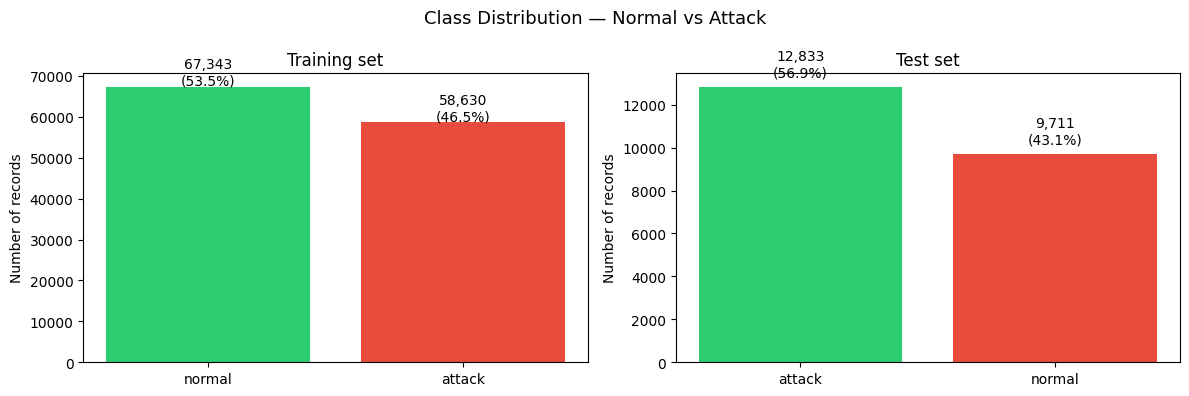

Chart saved to outputs/


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, df, title in zip(axes,
                          [train_df, test_df],
                          ["Training set", "Test set"]):
    counts = df["label"].value_counts()
    colors = ["#2ecc71", "#e74c3c"]
    ax.bar(counts.index, counts.values, color=colors)
    ax.set_title(title)
    ax.set_ylabel("Number of records")
    for i, (idx, val) in enumerate(counts.items()):
        ax.text(i, val + 500, f"{val:,}\n({val/len(df)*100:.1f}%)",
                ha="center", fontsize=10)

plt.suptitle("Class Distribution — Normal vs Attack", fontsize=13)
plt.tight_layout()
plt.savefig("../outputs/class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved to outputs/")

In [6]:
features_to_drop = ["label", "difficulty", "label_encoded"]

X_train = train_df.drop(columns=features_to_drop)
y_train = train_df["label_encoded"]

X_test  = test_df.drop(columns=features_to_drop)
y_test  = test_df["label_encoded"]

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"Features used: {X_train.shape[1]}")


X_train shape: (125973, 41)
X_test shape:  (22544, 41)
Features used: 41
